# MNIST Handwritten Digit Classification — End-to-End

A complete pipeline for training a CNN on the classic **MNIST** dataset (70,000 grayscale images of handwritten digits 0–9).

In [1]:
import torch, random
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
from torchvision.datasets import MNIST
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else
                       "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 1. Load MNIST Dataset with Transforms

In [2]:
train_transform = T.Compose([
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,))    # MNIST official mean & std
])
test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,))
])

train_ds = MNIST(root="./data", train=True,  download=True, transform=train_transform)
test_ds  = MNIST(root="./data", train=False, download=True, transform=test_transform)

print("Train samples:", len(train_ds))
print("Test samples :", len(test_ds))
print("Image shape  :", train_ds[0][0].shape)   # (1, 28, 28)

100%|██████████| 9.91M/9.91M [00:00<00:00, 26.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.16MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.39MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.41MB/s]


Train samples: 60000
Test samples : 10000
Image shape  : torch.Size([1, 28, 28])


## 2. Visualize Sample Images

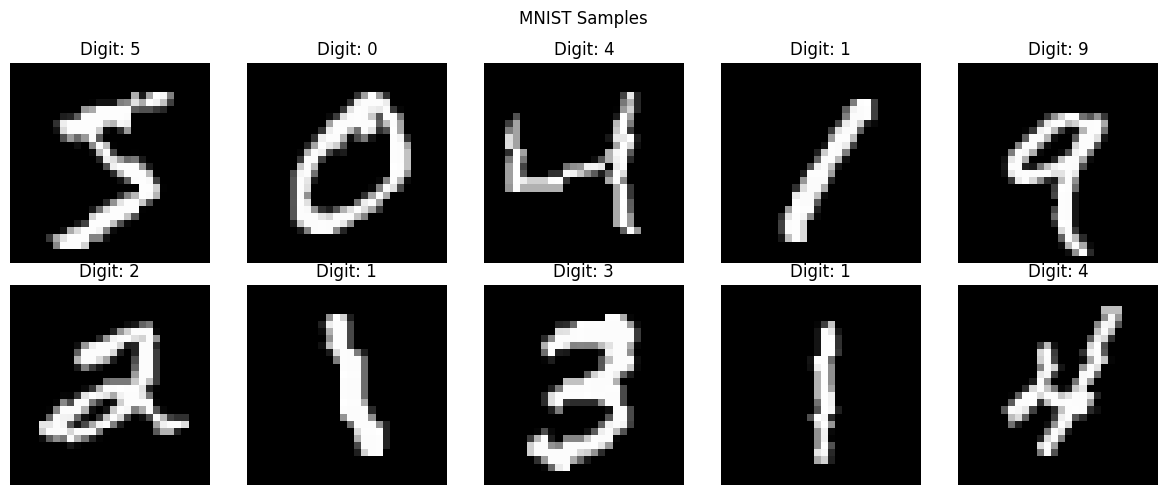

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for i in range(10):
    img, label = train_ds[i]
    img_raw = img * 0.3081 + 0.1307   # unnormalize
    axes[i].imshow(img_raw.squeeze(), cmap="gray")
    axes[i].set_title(f"Digit: {label}")
    axes[i].axis("off")
plt.suptitle("MNIST Samples")
plt.tight_layout(); plt.show()

## 3. DataLoaders

In [4]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)   # (64,1,28,28)
print("Batch y:", yb.shape)   # (64,)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch X: torch.Size([64, 1, 28, 28])
Batch y: torch.Size([64])


## 4. CNN Architecture

In [5]:
class MNISTNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),   # (B,32,28,28)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),  # (B,32,28,28)
            nn.ReLU(),
            nn.MaxPool2d(2),                  # (B,32,14,14)
            nn.Dropout2d(0.25),

            nn.Conv2d(32, 64, 3, padding=1),  # (B,64,14,14)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                  # (B,64,7,7)
            nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = MNISTNet().to(device)
print(model)
print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")

MNISTNet(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout2d(p=0.25, inplace=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)



## 5. Training

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)  # reduce LR every 3 epochs

def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
        with torch.no_grad():
            total_loss += loss.item() * xb.size(0)
            correct    += (model(xb).argmax(1) == yb).sum().item()
            total      += xb.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        total_loss += criterion(logits, yb).item() * xb.size(0)
        correct    += (logits.argmax(1) == yb).sum().item()
        total      += xb.size(0)
    return total_loss / total, correct / total

epochs = 10
history = {"tr_loss": [], "te_loss": [], "tr_acc": [], "te_acc": []}

for ep in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    te_loss, te_acc = evaluate(model, test_loader)
    scheduler.step()

    history["tr_loss"].append(tr_loss); history["te_loss"].append(te_loss)
    history["tr_acc"].append(tr_acc);   history["te_acc"].append(te_acc)
    print(f"Epoch {ep:02d} | Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | "
          f"Test Loss: {te_loss:.4f}, Acc: {te_acc:.4f}")

Epoch 01 | Train Loss: 0.2318, Acc: 0.9328 | Test Loss: 0.0474, Acc: 0.9848
Epoch 02 | Train Loss: 0.1146, Acc: 0.9675 | Test Loss: 0.0330, Acc: 0.9886
Epoch 03 | Train Loss: 0.0892, Acc: 0.9748 | Test Loss: 0.0290, Acc: 0.9906
Epoch 04 | Train Loss: 0.0635, Acc: 0.9809 | Test Loss: 0.0222, Acc: 0.9923
Epoch 05 | Train Loss: 0.0600, Acc: 0.9830 | Test Loss: 0.0211, Acc: 0.9935
Epoch 06 | Train Loss: 0.0556, Acc: 0.9834 | Test Loss: 0.0213, Acc: 0.9928
Epoch 07 | Train Loss: 0.0462, Acc: 0.9858 | Test Loss: 0.0187, Acc: 0.9934
Epoch 08 | Train Loss: 0.0438, Acc: 0.9866 | Test Loss: 0.0168, Acc: 0.9948
Epoch 09 | Train Loss: 0.0416, Acc: 0.9874 | Test Loss: 0.0171, Acc: 0.9946
Epoch 10 | Train Loss: 0.0375, Acc: 0.9895 | Test Loss: 0.0157, Acc: 0.9951


## 6. Plot Training Curves

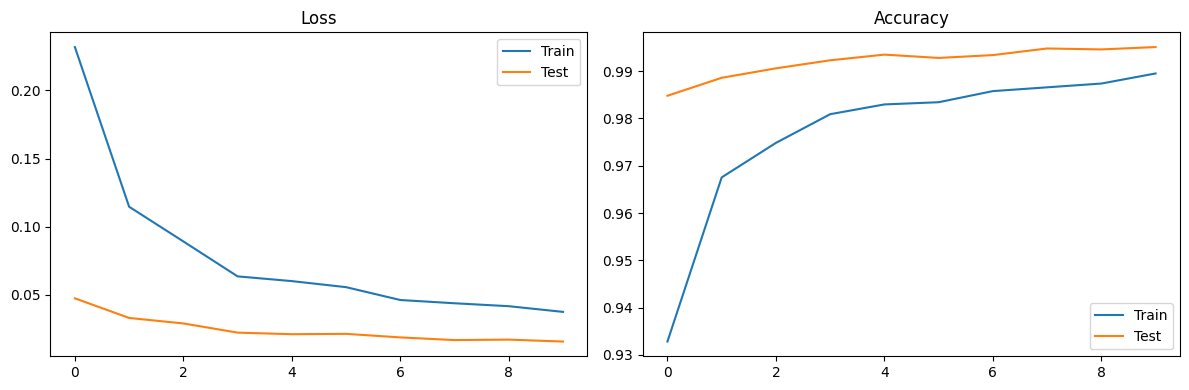

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["tr_loss"], label="Train"); ax1.plot(history["te_loss"], label="Test")
ax1.set_title("Loss"); ax1.legend()
ax2.plot(history["tr_acc"], label="Train"); ax2.plot(history["te_acc"], label="Test")
ax2.set_title("Accuracy"); ax2.legend()
plt.tight_layout(); plt.show()

## 7. Confusion Matrix

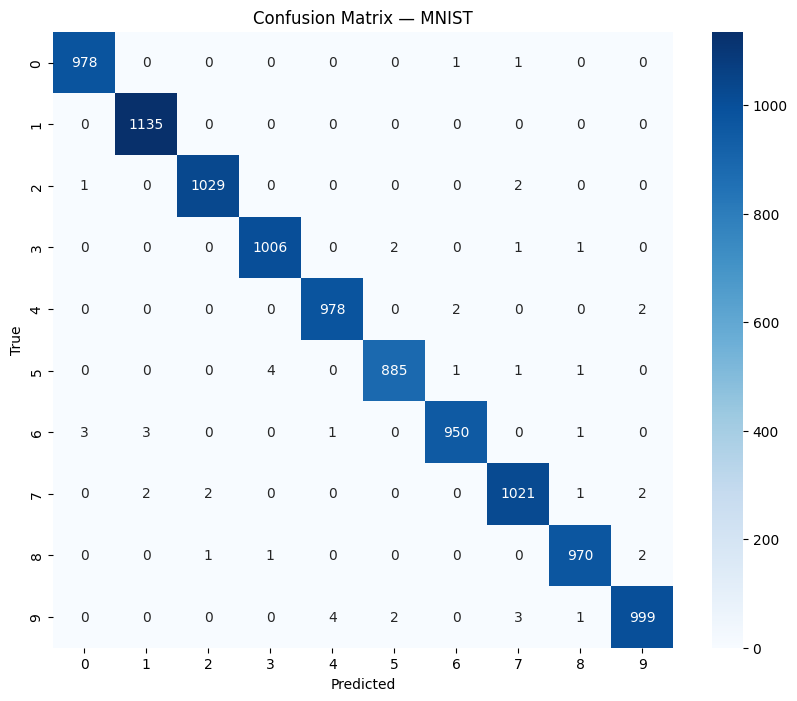

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       1.00      1.00      1.00      1010
           4       0.99      1.00      1.00       982
           5       1.00      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      1.00      1.00       974
           9       0.99      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      0.99      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [8]:
all_preds, all_true = [], []
model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        all_preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
        all_true.extend(yb.numpy())

cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion Matrix — MNIST"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

print(classification_report(all_true, all_preds))

## 8. Save & Load the Model

In [9]:
# Save
torch.save(model.state_dict(), "mnist_model.pth")
print("Model saved to mnist_model.pth")

# Load
model_loaded = MNISTNet().to(device)
model_loaded.load_state_dict(torch.load("mnist_model.pth", map_location=device))
model_loaded.eval()
print("Model loaded successfully!")

# Verify
_, te_acc = evaluate(model_loaded, test_loader)
print(f"Loaded model test accuracy: {te_acc:.4f}")

Model saved to mnist_model.pth
Model loaded successfully!


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Loaded model test accuracy: 0.9951
